## Problem Statement:

You have been given the data of all the passengers who onboarded Titanic. You have information such as:
- PassengerID, Survived(Yes/No), PassengerClass, Name, Gender, Age, Number of Sibling/Spouse, Number of parents/child, Ticket number, fare, cabin, Embarking city (C/Q/S)

Based on this dataset, you have to understand why didnt a passenger survive/Not survive the accident.
Then create an ML model to predict if a new person onboards a titanic, if he/she will survive the accident or not

In [ ]:
## Import necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [ ]:
## Load the dataset

df = pd.read_csv('/content/Titanic train dataset.csv')

In [ ]:
df

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### EDA

In [ ]:
df.shape

(891, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Gender       891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [ ]:
## Drop unnecessary columns

df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)

In [ ]:
df

,Survived,Pclass,Gender,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,NaN,S
887,1,1,female,19.0,0,0,30.0000,B42,S
888,0,3,female,NaN,1,2,23.4500,NaN,S
889,1,1,male,26.0,0,0,30.0000,C148,C


In [ ]:
## Handling null values

df.isnull().sum()

,0
Survived,0
Pclass,0
Gender,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,2


In [ ]:
## Cabin contains too many missing values

df.drop("Cabin", axis=1, inplace=True)

In [ ]:
## Replace null values in age with mean

df['Age'].fillna(df['Age'].mean(), inplace=True)

/tmp/ipykernel_1544/413372977.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Gender,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,2


In [ ]:
## As the embarked column has only 2 rows as null, we will simply delete those rows where we find null values

df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Gender,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [ ]:
## Handling duplicate values

df.duplicated().sum()

np.int64(111)

In [ ]:
## Remove the duplicates

df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(778, 8)

In [ ]:
## Seperate categorical and numerical columns

cat = df.select_dtypes(include='object').columns
num = df.select_dtypes(exclude='object').columns

In [ ]:
cat

Index(['Gender', 'Embarked'], dtype='object')

In [ ]:
num

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [ ]:
## Handling outliers using IQR

for i in num:
  Q1 = df[i].quantile(0.25)
  Q3 = df[i].quantile(0.75)
  IQR = Q3 - Q1

  LB = Q1 - (1.5 * IQR)
  UB = Q3 + (1.5 * IQR)

  df[i] = np.where(df[i] < LB, LB, df[i])
  df[i] = np.where(df[i] > UB, UB, df[i])

In [ ]:
df.shape

(778, 8)

In [ ]:
## Convert categorical variables to numerical

le = LabelEncoder()
for i in cat:
  df[i] = le.fit_transform(df[i])

In [ ]:
df

,Survived,Pclass,Gender,Age,SibSp,Parch,Fare,Embarked
0,0.0,3.0,1,22.000000,1.0,0.0,7.2500,2
1,1.0,1.0,0,38.000000,1.0,0.0,71.2833,0
2,1.0,3.0,0,26.000000,0.0,0.0,7.9250,2
3,1.0,1.0,0,35.000000,1.0,0.0,53.1000,2
4,0.0,3.0,1,35.000000,0.0,0.0,8.0500,2
...,...,...,...,...,...,...,...,...
885,0.0,3.0,0,39.000000,0.0,2.5,29.1250,1
887,1.0,1.0,0,19.000000,0.0,0.0,30.0000,2
888,0.0,3.0,0,29.699118,1.0,2.0,23.4500,2
889,1.0,1.0,1,26.000000,0.0,0.0,30.0000,0


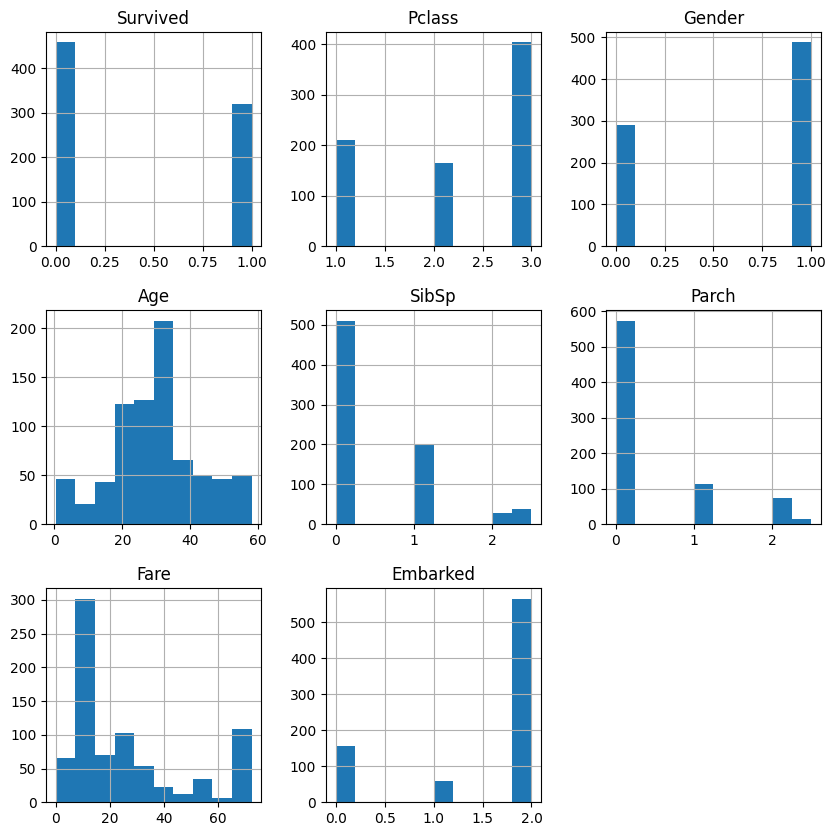

In [ ]:
## Univariate analysis

df.hist(figsize=(10,10))
plt.show()

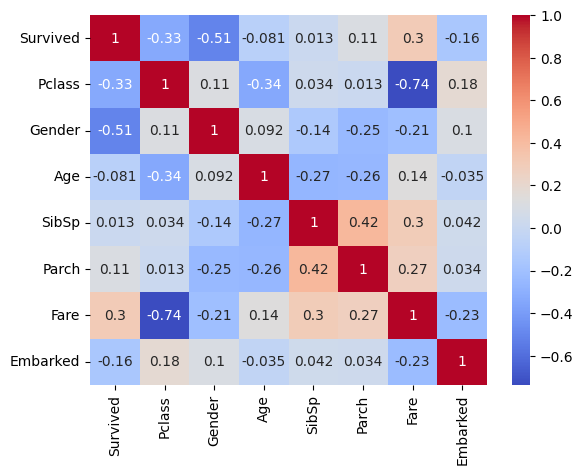

In [ ]:
## correlation matrix

sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')
plt.show()

### Model building

In [ ]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [ ]:
X

,Pclass,Gender,Age,SibSp,Parch,Fare,Embarked
0,3.0,1,22.000000,1.0,0.0,7.2500,2
1,1.0,0,38.000000,1.0,0.0,71.2833,0
2,3.0,0,26.000000,0.0,0.0,7.9250,2
3,1.0,0,35.000000,1.0,0.0,53.1000,2
4,3.0,1,35.000000,0.0,0.0,8.0500,2
...,...,...,...,...,...,...,...
885,3.0,0,39.000000,0.0,2.5,29.1250,1
887,1.0,0,19.000000,0.0,0.0,30.0000,2
888,3.0,0,29.699118,1.0,2.0,23.4500,2
889,1.0,1,26.000000,0.0,0.0,30.0000,0


In [ ]:
y

,Survived
0,0.0
1,1.0
2,1.0
3,1.0
4,0.0
...,...
885,0.0
887,1.0
888,0.0
889,1.0


In [ ]:
## Divide the dataset into train-test

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size =0.7)

In [ ]:
model = LogisticRegression()

## Building the model

model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
## Model evaluation


cm = confusion_matrix(y_test, y_pred)
print(cm)

[[109  13]
 [ 44  68]]


In [ ]:
acc = accuracy_score(y_test, y_pred)
print(acc)

0.7564102564102564


In [ ]:
precison = precision_score(y_test, y_pred)
print(precison)

0.8395061728395061


In [ ]:
recall = recall_score(y_test, y_pred)
print(recall)

0.6071428571428571


In [ ]:
f1s = f1_score(y_test, y_pred)
print(f1s)

0.7046632124352331


Model building is done with 75% accuracy

In [ ]:
new_passenger = {
    'Pclass': 1,
    'Gender': 0,
    'Age': 25,
    'SibSp': 1,
    'Parch': 0,
    'Fare': 30,
    'Embarked': 2
}

In [ ]:
new_df = pd.DataFrame(new_passenger, index=[0])

In [ ]:
new_df

,Pclass,Gender,Age,SibSp,Parch,Fare,Embarked
0,1,0,25,1,0,30,2


In [ ]:
## Predict the output class

pred = model.predict(new_df)

In [ ]:
pred

array([1.])

In [ ]:
## Predict survival probability

prob = model.predict_proba(new_df)
print(prob)

[[0.1218792 0.8781208]]
